# **Project 1: Working with CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.

In [9]:
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("All systems go! Ready for AI Engineering.")

TensorFlow version: 2.16.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All systems go! Ready for AI Engineering.


# 1. Data Processing

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, precision_recall_fscore_support
from IPython.display import display
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the raw CIFAR-10 dataset

In [2]:
# This return two tuple containing NumPy arrays
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalization (Feature Scaling)

In [3]:
# Convert pixel values from [0, 255] to [0, 1] for numerical stability
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Resizing and Data Augmentation

In [4]:
# Resize images to a standard size (64x64 for better CNN performance)
x_train_resized = tf.image.resize(x_train, [64, 64])
x_test_resized = tf.image.resize(x_test, [64, 64])

print(f'Training data shape after resizing: {x_train_resized.shape}')
print(f'Test data shape after resizing: {x_test_resized.shape}')

# Data Augmentation using ImageDataGenerator


# Create an ImageDataGenerator for training data with augmentation
augmentation = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Fit augmentation on training data (compute statistics)
augmentation.fit(x_train_resized)


2026-02-26 19:11:51.114545: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-02-26 19:11:51.116302: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-26 19:11:51.116320: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-26 19:11:51.118241: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-26 19:11:51.118264: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Training data shape after resizing: (50000, 64, 64, 3)
Test data shape after resizing: (10000, 64, 64, 3)


# Preparing Labels: One-Hot Encoding

In [5]:
# Convert class vectors (integers) to binary class matrices
# Necessary for the Categorical Crossentropy loss function

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Use resized data for model training
x_train = x_train_resized
x_test = x_test_resized

# 2. Model Architecture: 
 - Design a CNN architecture suitable for image classification.

In [6]:
# Designing a CNN architecture adapted for 64x64 resized images

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

model = Sequential()

# Stack two convolutional layers with 32 Filters (3x3) and same Padding
# Use a max pooling layer and Dropout 
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# Flatten the output
model.add(Flatten())

# Add a Dense layer with 128 units
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Classification layer (10 classes of CIFAR-10)
model.add(Dense(10, activation='softmax'))

model.summary()

/opt/anaconda3/envs/machine_learning/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,962 (8.08 MB)

 Trainable params: 2,117,962 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Model Training

In [7]:
# Define Early Stopping callback
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

def opt_techniques(optim):
  model.compile(loss='categorical_crossentropy', optimizer=optim, metrics=['accuracy'])

# Compile the Model, optimizer: stochastic gradient descent 'sgd' or 'adam'
opt_techniques(optim='adam')

In [10]:
# Training Model
BATCH_SIZE = 128
history = model.fit(x_train, y_train, epochs=25, batch_size=BATCH_SIZE)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.4756 - loss: 1.6751
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4836 - loss: 1.7108
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4804 - loss: 1.7737
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4822 - loss: 1.7946
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.4784 - loss: 1.8810
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.4813 - loss: 1.9009
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.4810 - loss: 2.0155
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4769 - loss: 2.0557
Epoch 9/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.4814 - loss: 2.0640
Epoch 10/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4766 - loss: 2.2451
Epoch 11/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4781 - loss: 2.2816
Epoch 12/25
391/391 ━━━━━━━━━━

# 4. Model Evaluation

Test loss: 0.9096 | Test accuracy: 0.6866
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.72      0.72      0.72      1000
  automobile       0.83      0.81      0.82      1000
        bird       0.62      0.48      0.54      1000
         cat       0.45      0.53      0.49      1000
        deer       0.60      0.64      0.62      1000
         dog       0.57      0.62      0.59      1000
        frog       0.78      0.74      0.76      1000
       horse       0.78      0.75      0.76      1000
        ship       0.79      0.80      0.79      1000
       truck       0.79      0.77      0.78      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



,class,precision,recall,f1
0,airplane,0.724975,0.717,0.720965
1,automobile,0.827411,0.815,0.821159
2,bird,0.616368,0.482,0.540965
3,cat,0.449789,0.533,0.487872
4,deer,0.598322,0.642,0.619392
5,dog,0.570768,0.617,0.592984
6,frog,0.777895,0.739,0.757949
7,horse,0.780437,0.750,0.764916
8,ship,0.787046,0.802,0.794453
9,truck,0.788718,0.769,0.778734


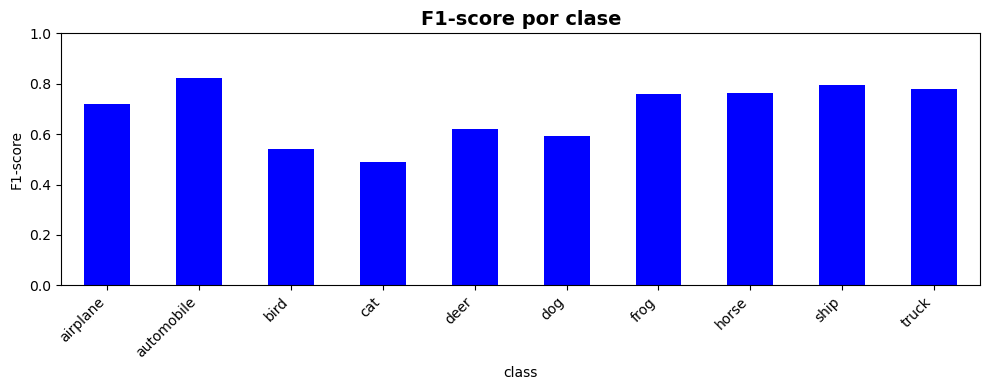

In [ ]:
# Complete model evaluation: loss/accuracy, classification report, and metrics 

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Evaluate in the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}')

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model.predict(x_test)
y_pred = np.argmax(probs, axis=1)

# Class Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes))

# Metrics by class (precision, recall, f1)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
df_metrics = pd.DataFrame({'class': classes, 'precision': precision, 'recall': recall, 'f1': f1})
display(df_metrics)

# F1 plot by class
plt.figure(figsize=(10,4))
df_metrics.set_index('class')['f1'].plot(kind='bar', ylim=(0,1), color='blue')
plt.title('F1-score por clase', fontsize=14, fontweight='bold')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

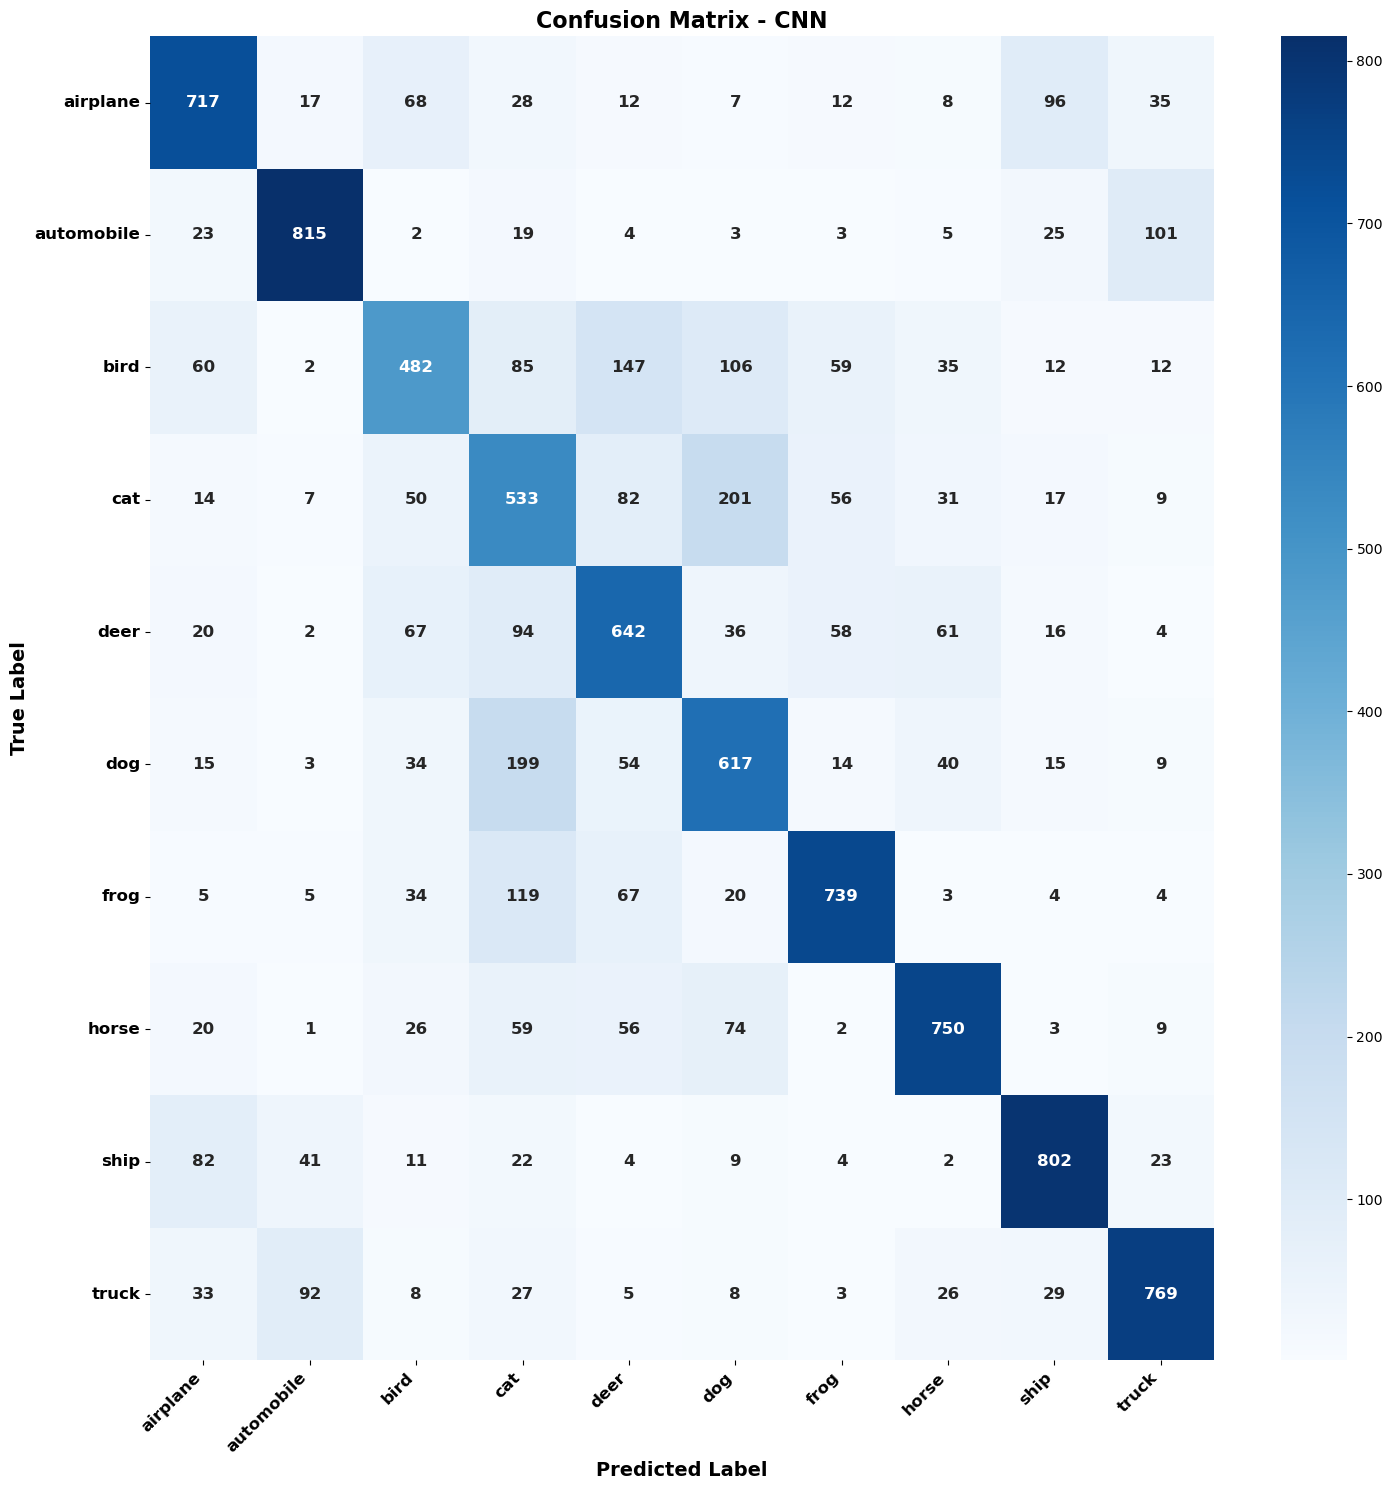

In [ ]:
# Confusion Matrix (restaurada): etiquetas con nombre, fuente más grande y negrita
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Use existing y_true and y_pred computed in the previous evaluation cell
cm = confusion_matrix(y_true, y_pred)

# Use class names defined earlier
labels = classes

plt.figure(figsize=(15, 15))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size":12, "weight":"bold"})
ax.set_title('Confusion Matrix - CNN', fontsize=16, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Transfer Learning
- Evaluate the accuracy of your model on a pre-trained models like ImagNet, VGG16, Inception... (pick one an justify your choice)
- Perform transfer learning with your chosen pre-trained models i.e., you will probably try a few and choose the best one.

# VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models

# 1. Preprocessing Layer: Resize images for better VGG16 performance
# # VGG16 was trained on 224x224, but we can upscale 32x32 to 64x64 or 96x96
img_augmentation = Sequential([
    layers.Resizing(64, 64), 
    layers.RandomFlip("horizontal")
])

In [ ]:
# 2. Load VGG16 with Pre-trained Weights (ImageNet)
# include_top=False removes the final 1000-class classification head
base_model = VGG16(weights='imagenet',
                   include_top=False, 
                   input_shape=(224, 224, 3)
                  )

In [ ]:
# 3. Freeze the Base Model
# This ensures we don't destroy the pre-trained knowledge during initial training
base_model.trainable = False

In [ ]:
# 4. Build the Final CNN Architecture
model_vgg = models.Sequential([
  img_augmentation,
  base_model,
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dropout(0.5),
  layers.Dense(10, activation='softmax')
])


In [ ]:
# 5. Compile and Train
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train for a new epochs to see the difference 
history_vgg = model_vgg.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 561s 358ms/step - accuracy: 0.5480 - loss: 1.3016 - val_accuracy: 0.6458 - val_loss: 1.0290
Epoch 2/10
1352/1563 ━━━━━━━━━━━━━━━━━━━━ 1:07 321ms/step - accuracy: 0.6101 - loss: 1.1104

KeyboardInterrupt: 

Test loss: 0.8605 | Test accuracy: 0.6995
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 250ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.76      0.74      0.75      1000
  automobile       0.76      0.82      0.79      1000
        bird       0.70      0.57      0.63      1000
         cat       0.52      0.51      0.51      1000
        deer       0.60      0.70      0.64      1000
         dog       0.62      0.59      0.61      1000
        frog       0.70      0.75      0.73      1000
       horse       0.76      0.74      0.75      1000
        ship       0.78      0.82      0.80      1000
       truck       0.82      0.75      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



,class,precision,recall,f1
0,airplane,0.755374,0.738,0.746586
1,automobile,0.759070,0.816,0.786506
2,bird,0.698413,0.572,0.628917
3,cat,0.521561,0.508,0.514691
4,deer,0.595097,0.704,0.644984
5,dog,0.620545,0.592,0.605937
6,frog,0.703081,0.753,0.727185
7,horse,0.758727,0.739,0.748734
8,ship,0.779886,0.822,0.800389
9,truck,0.817193,0.751,0.782699


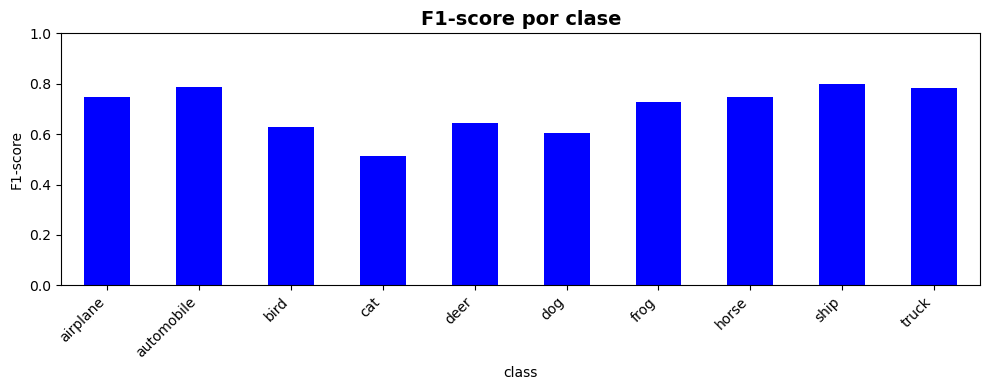

In [ ]:
# Complete model evaluation: loss/accuracy, classification report, and metrics 

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Evaluate in the test set
test_loss, test_acc = model_vgg.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}')

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model_vgg.predict(x_test)
y_pred = np.argmax(probs, axis=1)

# Class Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes))

# Metrics by class (precision, recall, f1)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
df_metrics = pd.DataFrame({'class': classes, 'precision': precision, 'recall': recall, 'f1': f1})
display(df_metrics)

# F1 plot by class
plt.figure(figsize=(10,4))
df_metrics.set_index('class')['f1'].plot(kind='bar', ylim=(0,1), color='blue')
plt.title('F1-score por clase', fontsize=14, fontweight='bold')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# InceptionV3 Implementation

In [ ]:

from tensorflow.keras import layers, models

# Loading InceptionV3 with ImagNet weights
# Note: input_shape must be at least (75, 75, 3) for Inception
base_model_inception = base_model = tf.keras.applications.InceptionV3(
  include_top=True,
  weights='imagenet', 
  input_tensor=None, 
  input_shape=None, 
  pooling=None,
  classes=1000, 
  classifier_activation='softmax'
)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
